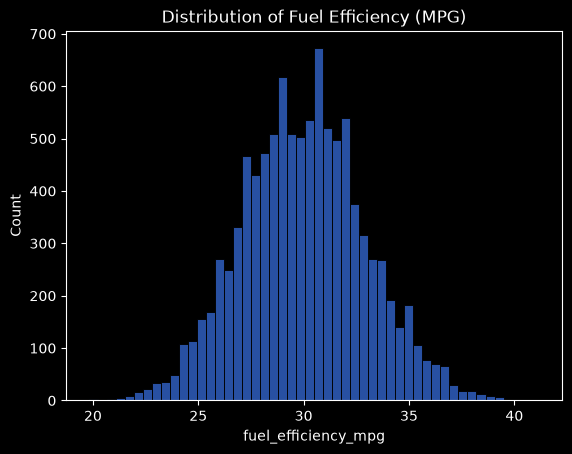

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df_full = pd.read_csv(url)

cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_full[cols].copy()

sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.show()

# Q1

In [2]:
missing_counts = df.isnull().sum()
missing_col = missing_counts[missing_counts > 0].index[0]
print("Missing values per column:\n", missing_counts)
print(f"\nColumn with missing values: {missing_col}")

Missing values per column:
 engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Column with missing values: horsepower


# Q2

In [3]:
hp_median = df['horsepower'].median()
print(f"Median of horsepower: {hp_median}")

Median of horsepower: 254.0


# Define Helper Functions

In [4]:
# Helper to split the dataset
def split_data(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train+n_val]].copy()
    df_test = df.iloc[idx[n_train+n_val:]].copy()

    y_train = df_train.pop('fuel_efficiency_mpg').values
    y_val = df_val.pop('fuel_efficiency_mpg').values
    y_test = df_test.pop('fuel_efficiency_mpg').values

    return df_train, df_val, df_test, y_train, y_val, y_test

# Helper to prepare X matrix
def prepare_X(df, fill_value):
    df_num = df.copy()
    df_num = df_num.fillna(fill_value)
    return df_num.values

# Linear Regression (without regularization)
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

# Linear Regression (with Ridge regularization)
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

# Root Mean Squared Error
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

# Q3

In [5]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=42)

# Calculate the mean of the missing column using ONLY the training set
mean_val = df_train[missing_col].mean()

# Option A: Fill with 0
X_train_0 = prepare_X(df_train, fill_value=0)
w_0_0, w_0 = train_linear_regression(X_train_0, y_train)
X_val_0 = prepare_X(df_val, fill_value=0)
y_pred_0 = w_0_0 + X_val_0.dot(w_0)
rmse_0 = round(rmse(y_val, y_pred_0), 3)

# Option B: Fill with mean
X_train_mean = prepare_X(df_train, fill_value=mean_val)
w_0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
X_val_mean = prepare_X(df_val, fill_value=mean_val)
y_pred_mean = w_0_mean + X_val_mean.dot(w_mean)
rmse_mean = round(rmse(y_val, y_pred_mean), 3)

print(f"RMSE filling NAs with 0:    {rmse_0}")
print(f"RMSE filling NAs with mean: {rmse_mean}")

RMSE filling NAs with 0:    2.205
RMSE filling NAs with mean: 2.202


# Q4

In [6]:
# Fill NAs with 0 for this question
X_train = prepare_X(df_train, fill_value=0)
X_val = prepare_X(df_val, fill_value=0)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
best_rmse = float('inf')
best_r = None

for r in r_values:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    print(f"r = {r:<5} | RMSE = {score:.4f}")

    # Track the best (smallest) r in case of a tie
    if score < best_rmse:
        best_rmse = score
        best_r = r

print(f"\nBest r is {best_r} with an RMSE of {best_rmse}")

r = 0     | RMSE = 2.2053
r = 0.01  | RMSE = 2.2058
r = 0.1   | RMSE = 2.2241
r = 1     | RMSE = 2.3492
r = 5     | RMSE = 2.4094
r = 10    | RMSE = 2.4195
r = 100   | RMSE = 2.4292

Best r is 0 with an RMSE of 2.2053


# Q5

In [7]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

for seed in seeds:
    df_t, df_v, df_ts, y_t, y_v, y_ts = split_data(df, seed=seed)

    X_t = prepare_X(df_t, fill_value=0)
    X_v = prepare_X(df_v, fill_value=0)

    w_0, w = train_linear_regression(X_t, y_t)
    y_pred = w_0 + X_v.dot(w)
    score = rmse(y_v, y_pred)

    rmse_scores.append(score)

std_dev = round(np.std(rmse_scores), 3)
print(f"Standard Deviation of RMSE scores: {std_dev}")

Standard Deviation of RMSE scores: 0.029


# Q6

In [8]:
# Split the dataset using seed 9
df_t, df_v, df_ts, y_t, y_v, y_ts = split_data(df, seed=9)

# Combine train and validation datasets
df_full_train = pd.concat([df_t, df_v]).reset_index(drop=True)
y_full_train = np.concatenate([y_t, y_v])

# Train a model with r=0.001
X_full_train = prepare_X(df_full_train, fill_value=0)
w_0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# Evaluate on the test dataset
X_test = prepare_X(df_ts, fill_value=0)
y_pred = w_0 + X_test.dot(w)
final_rmse = round(rmse(y_ts, y_pred), 3)

print(f"RMSE on test dataset: {final_rmse}")

RMSE on test dataset: 2.236
